<a href="https://colab.research.google.com/github/carolcalandrine/Analise-churn/blob/main/projeto_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Churn

Churn refere-se ao momento em que um cliente deixa de utilizar os serviços ou produtos de uma empresa. Esse é um dos principais desafios enfrentados por organizações, especialmente em setores como telecomunicações, bancos e serviços por assinatura, pois a perda de clientes impacta diretamente na receita e no crescimento do negócio.

Dessa forma, compreender os fatores que levam um cliente a cancelar um serviço é essencial para a criação de estratégias de retenção mais eficientes.

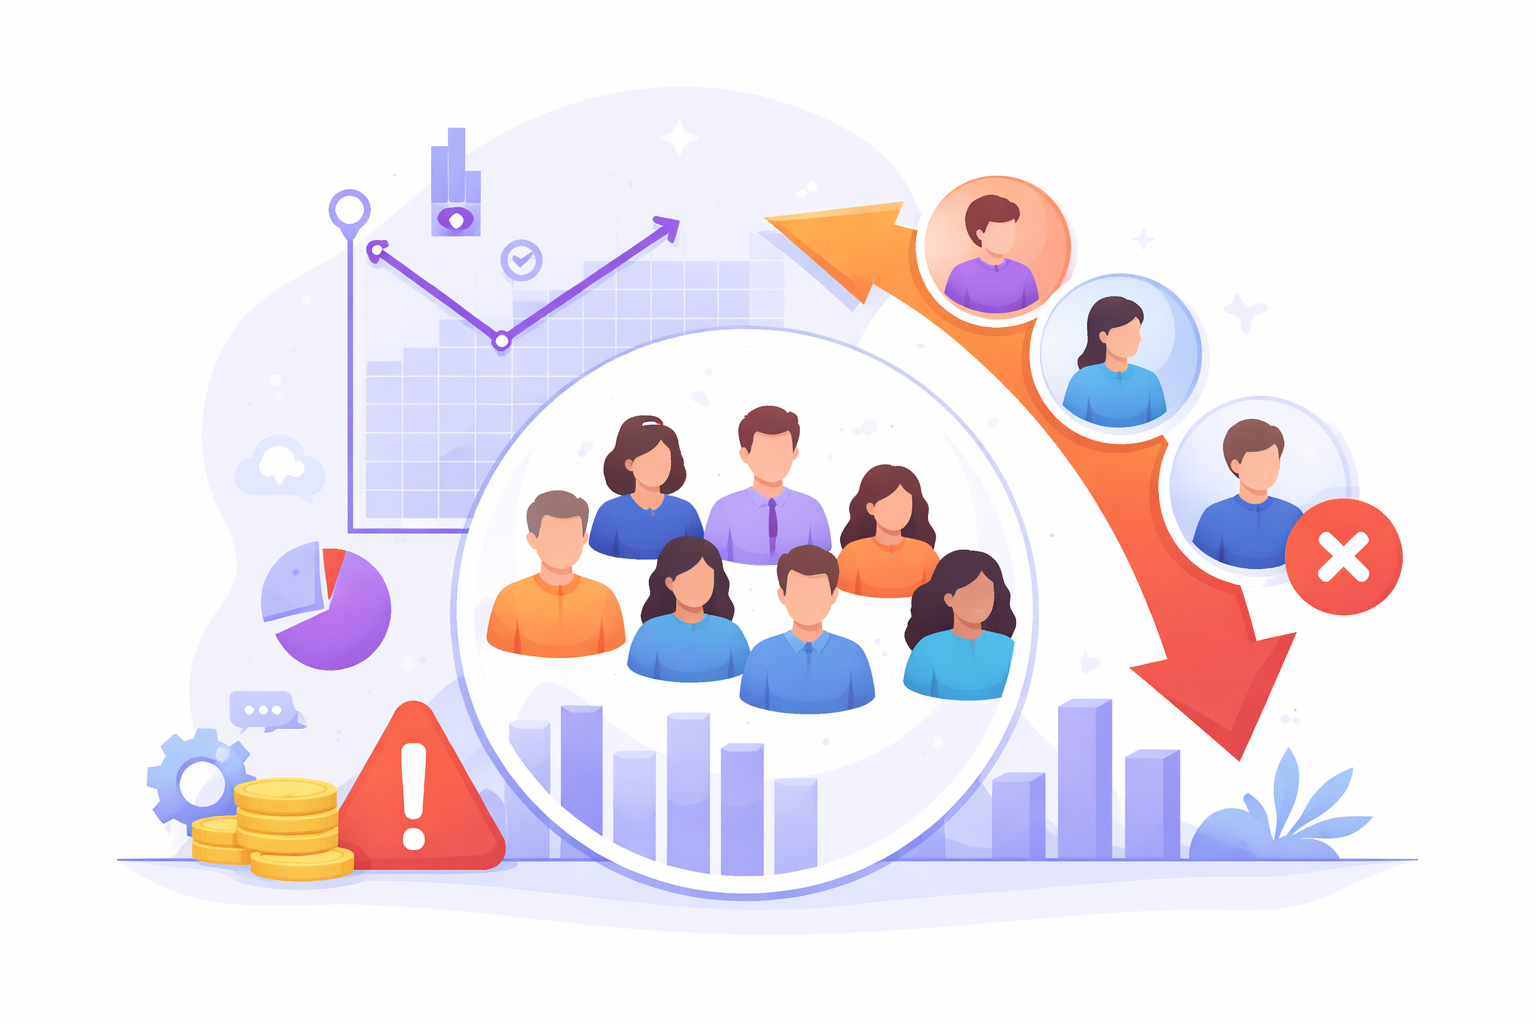

## Objetivo do estudo
Realizar uma análise exploratória dos dados para investigar a hipótese de aumento na taxa de churn (cancelamento de clientes) em uma plataforma de serviços por assinatura.

##  Importação de Bibliotecas

In [2]:
#importação de bibliotecas
import pandas as pd #manipular tabelas
import numpy as np #operações
import seaborn as sb #manipular gráficos
import matplotlib.pyplot as plt #manipular gráficos

In [3]:
# Importação do arquivo .csv
df = pd.read_csv('/content/customer_churn_with_months.csv')

# Limpar os nomes das colunas
df.columns = df.columns.str.strip()  #Remove espaços desnecessários

print(df.columns.tolist())

['ID', 'Tipo de empresa', 'Fundação da empresa', 'Possui mais de um sócio', 'Funcionários', 'Meses de permanência', 'Utiliza serviços financeiros', 'PossuiContador', 'Faz conciliação bancária', 'Frequência de utilização de feature do sistema: Módulo financeiro', 'Frequência de utilização de feature do sistema: Emissão de nota fiscal', 'Frequência de utilização de feature do sistema: Integração bancária', 'Frequência de utilização de feature do sistema: Módulo de vendas', 'Frequência de utilização de feature do sistema: Relatórios', 'Frequência de utilização de feature do sistema: Utilização de APIs de integração', 'Contrato', 'Emite boletos', 'Emite boletos.1', 'Tipo de pagamento', 'Receita mensal', 'Receita total', 'Churn', 'mes_churn']


## Dicionário das variáveis

- `customerID`: Identificador único dos clientes
- `Tipo de empresa`: Se a empresa é Micro empresa ou Pequena empresa
- `Fundação da empresa`: Anos de fundação
- `Possui mais de sócio`: Corresponde a sim ou não
- `Funcionários`: Se possui até 5 ou 6 ou mais funcionários
- `Meses de permanência`: 	A quantidade de meses que o cliente está contratado
- `Utiliza serviços financeiros`: Corresponde a Sim ou Não
- `PossuiContador`: Corresponde a Sim ou Não
- `Faz conciliação bancária`: Se a conciliação é automática, manual ou não faz
- `Módulo financeiro`: Uso frequente, pouco uso e nunca utilizou
- `Relatórios`: Uso frequente, pouco uso e nunca utilizou
- `Utilização de APIs de integração`: Se a conciliação é automática, manual ou não faz
- `Contrato`: Mês-a-mês, trimestral e anual
- `Emite boletos`: Se a transação é feita por boletos: 1 ou 0
- `Emite boletos.1`: Se a transação é feita por boletos: Yes ou No
- `Tipo de pagamento`: Cartão de crédito e Boleto
- `Receita mensal`:	A transação por mês realizada por esse cliente
- `Receita total`: A receita total realizada por esse cliente
- `Churn`: Se a houve o churn desse cliente: Sim ou Não
- `mes_churn`: O mês que ocorreu o churn   

## Visão Geral dos Dados

In [6]:
# Overview da tabela
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')

info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': round(df.isnull().mean() * 100,2),
    'Valores únicos': df.nunique(),
    'Exemplo de valores': df.apply(lambda x: x.unique()[:3])
})
info

Linhas: 7043 | Colunas: 23


,Tipo,Nulos,% Nulos,Valores únicos,Exemplo de valores
ID,int64,0,0.00,7043,"[1, 2, 4]"
Tipo de empresa,object,0,0.00,2,"[Micro empresa, Pequena empresa]"
Fundação da empresa,int64,0,0.00,21,"[2016, 2018, 2019]"
Possui mais de um sócio,object,0,0.00,2,"[Sim, Não]"
Funcionários,object,0,0.00,2,"[até 5 funcionários, 6 ou mais funcionários]"
Meses de permanência,int64,0,0.00,73,"[1, 34, 45]"
Utiliza serviços financeiros,object,0,0.00,2,"[Não, Sim]"
PossuiContador,object,682,9.68,2,"[nan, Não , Sim]"
Faz conciliação bancária,object,0,0.00,3,"[automática, manual, não faz]"
Frequência de utilização de feature do sistema: Módulo financeiro,object,0,0.00,3,"[Pouco uso, Uso frequente, Nunca utilizou]"


## Exploração Univariada

#### Variáveis Categóricas



Tipo de empresa

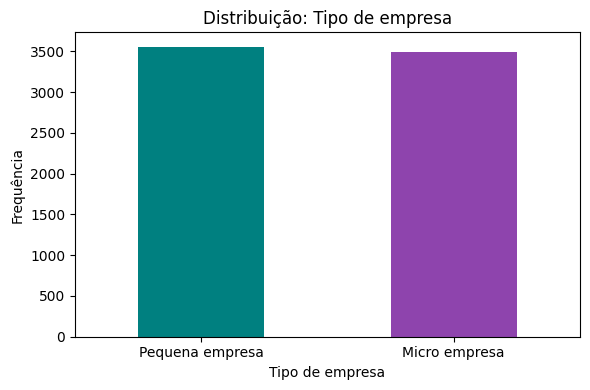

Valores únicos: ['Micro empresa' 'Pequena empresa']
Frequência absoluta: Tipo de empresa
Pequena empresa    3555
Micro empresa      3488
Frequência relativa: Tipo de empresa
Pequena empresa    50.48
Micro empresa      49.52


In [ ]:
# Análise da coluna 'Tipo de empresa'

col = 'Tipo de empresa' #col é o nome da coluna (variável)

# Valores únicos
valores_unicos = df[col].unique()

# Frequência Absoluta e Relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True)* 100,2)

# Visualização
plt.figure(figsize=(6,4)) #Define o tamanho da imagem
freq_abs.plot(kind='bar', color=['#008080','#8e44ad']) #kind=bar é o tipo de gráfico, color= cor do gráfico
plt.title('Distribuição: Tipo de empresa') #titulo
plt.xlabel('Tipo de empresa') #nome dos eixos
plt.ylabel('Frequência')
plt.xticks(rotation=0) # rotação
plt.tight_layout() #Ajusta o layout
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Possui mais de um sócio

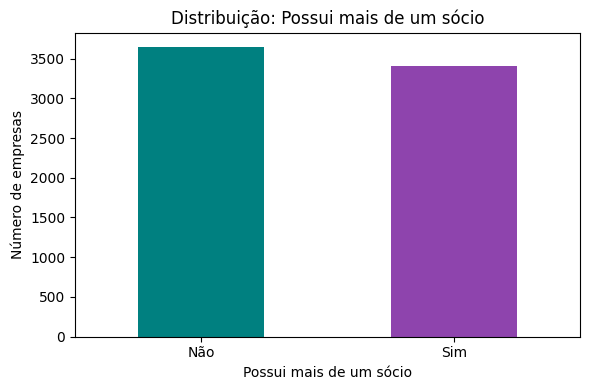

Valores únicos: ['Sim' 'Não']
Frequência absoluta: Possui mais de um sócio
Não    3641
Sim    3402
Frequência relativa: Possui mais de um sócio
Não    51.7
Sim    48.3


In [ ]:
# Análise da coluna 'Possui mais de um sócio'

col = 'Possui mais de um sócio'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência Relativa e Absoluta
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Visualização
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad'])
plt.title('Distribuição: Possui mais de um sócio')
plt.xlabel('Possui mais de um sócio')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Funcionários

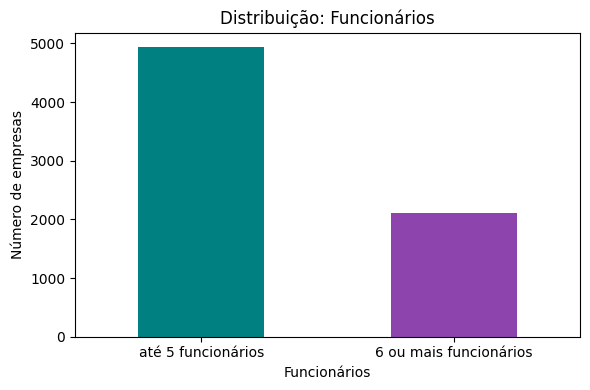

Valores únicos: ['até 5 funcionários' '6 ou mais funcionários']
Frequência absoluta: Funcionários
até 5 funcionários        4933
6 ou mais funcionários    2110
Frequência relativa: Funcionários
até 5 funcionários        70.04
6 ou mais funcionários    29.96


In [ ]:
# Análise da variável 'Funcionários'
col = 'Funcionários'

#Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Visualização
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad'])
plt.title('Distribuição: Funcionários')
plt.xlabel('Funcionários')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Utiliza Serviços Financeiros

Valores únicos: ['Não' 'Sim']


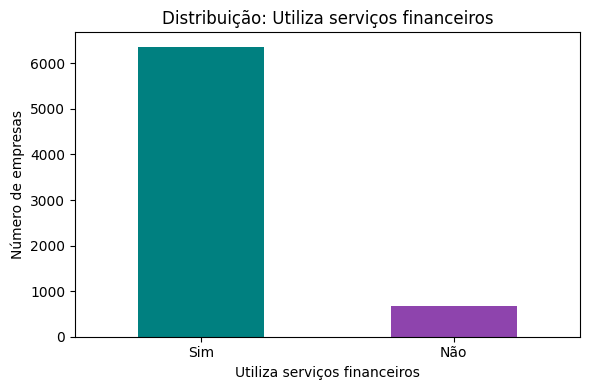

Valores únicos: ['Não' 'Sim']
Frequência absoluta: Utiliza serviços financeiros
Sim    6361
Não     682
Frequência relativa: Utiliza serviços financeiros
Sim    90.32
Não     9.68


In [ ]:
# Análise da coluna 'Utiliza serviços financeiros'
col = 'Utiliza serviços financeiros'

# Valores únicos
valores_unicos = df[col].unique()
print(f'Valores únicos: {df[col].unique()}')

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad'])
plt.title('Distribuição: Utiliza serviços financeiros')
plt.xlabel('Utiliza serviços financeiros')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')


Essa variável é uma variável categórica ordinal. Sendo assim pode-se dizer que a maioria dos clientes utilizam serviços financeiros. Então qual seria a relação do churn com essa variável? Quem possui ou não serviços financeiros tende a cancelar a assinatura ?

Possui Contador

Valores únicos: [nan 'Não ' 'Sim']


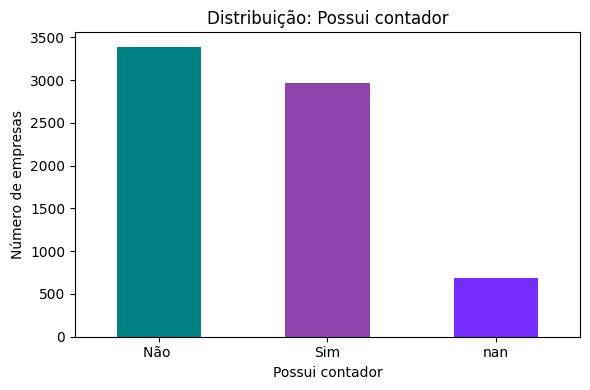

Valores únicos: [nan 'Não ' 'Sim']
Frequência absoluta: PossuiContador
Não     3390
Sim     2971
NaN      682
Frequência relativa: PossuiContador
Não     48.13
Sim     42.18
NaN      9.68


In [ ]:
#Análise da coluna 'PossuiContador'
col = 'PossuiContador'

#Valores unicos
valores_unicos = df[col].unique()
print(f'Valores únicos: {valores_unicos}')

#Nulos
nulos = df[col].isnull().sum()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts(dropna=False) # dropna=False para considerar os valores vazios
freq_rel = round(df[col].value_counts(normalize=True, dropna=False) * 100,2)

# Gráfico de barra
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad', '#762CFA'])
plt.title('Distribuição: Possui contador')
plt.xlabel('Possui contador')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Esse 'nan' seriam os valores vazios que não obtiveram resultados em relação a pergunta: se o cliente possui ou não contador sendo 9,68%

Faz conciliação bancária

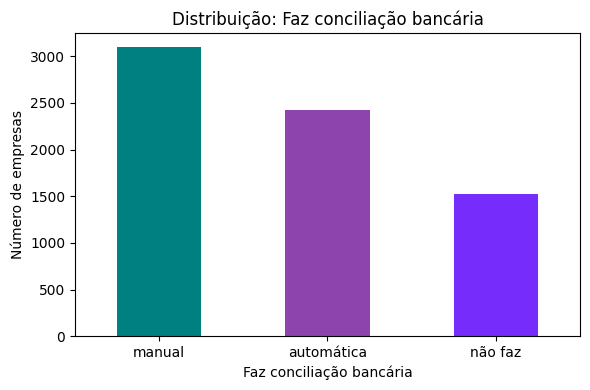

Valores únicos: ['automática' 'manual' 'não faz']
Frequência absoluta: Faz conciliação bancária
manual        3096
automática    2421
não faz       1526
Frequência relativa: Faz conciliação bancária
manual        43.96
automática    34.37
não faz       21.67


In [ ]:
# Análise da coluna 'Faz conciliação bancária'

col = 'Faz conciliação bancária'

#Valores únicos
valores_unicos = df[col].unique()

#Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad', '#762CFA'])
plt.title('Distribuição: Faz conciliação bancária')
plt.xlabel('Faz conciliação bancária')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Frequência de utilização de feature do sistema: Módulo financeiro

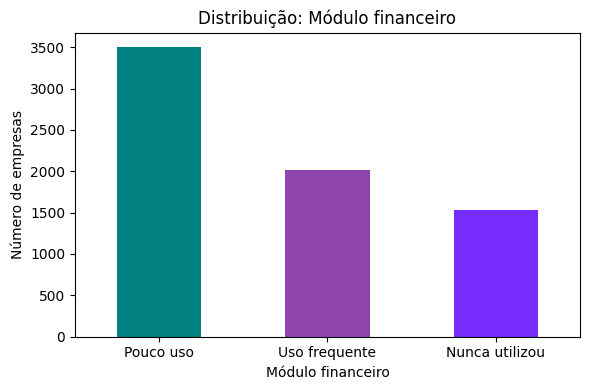

Valores únicos: ['Pouco uso' 'Uso frequente' 'Nunca utilizou']
Frequência absoluta: Frequência de utilização de feature do sistema: Módulo financeiro
Pouco uso         3498
Uso frequente     2019
Nunca utilizou    1526
Frequência relativa: Frequência de utilização de feature do sistema: Módulo financeiro
Pouco uso         49.67
Uso frequente     28.67
Nunca utilizou    21.67


In [ ]:
# Análise da coluna 'Módulo financeiro'

col = 'Frequência de utilização de feature do sistema: Módulo financeiro'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad', '#762CFA'])
plt.title('Distribuição: Módulo financeiro')
plt.xlabel('Módulo financeiro')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Emissão de nota fiscal

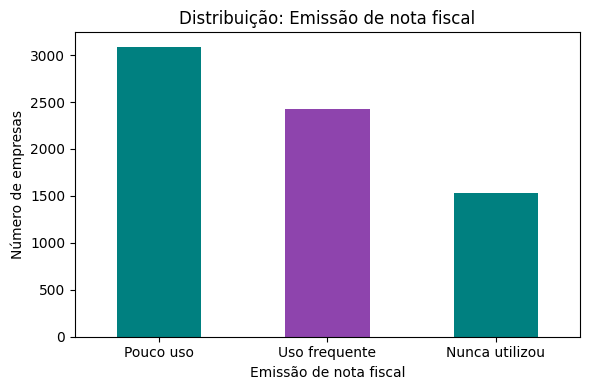

Valores únicos: ['Uso frequente' 'Pouco uso' 'Nunca utilizou']
Frequência absoluta: Frequência de utilização de feature do sistema: Emissão de nota fiscal
Pouco uso         3088
Uso frequente     2429
Nunca utilizou    1526
Frequência relativa: Frequência de utilização de feature do sistema: Emissão de nota fiscal
Pouco uso         43.84
Uso frequente     34.49
Nunca utilizou    21.67


In [ ]:
# Análise da coluna 'Emissão de nota fiscal'

col = 'Frequência de utilização de feature do sistema: Emissão de nota fiscal'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color= ['#008080','#8e44ad'])
plt.title('Distribuição: Emissão de nota fiscal')
plt.xlabel('Emissão de nota fiscal')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

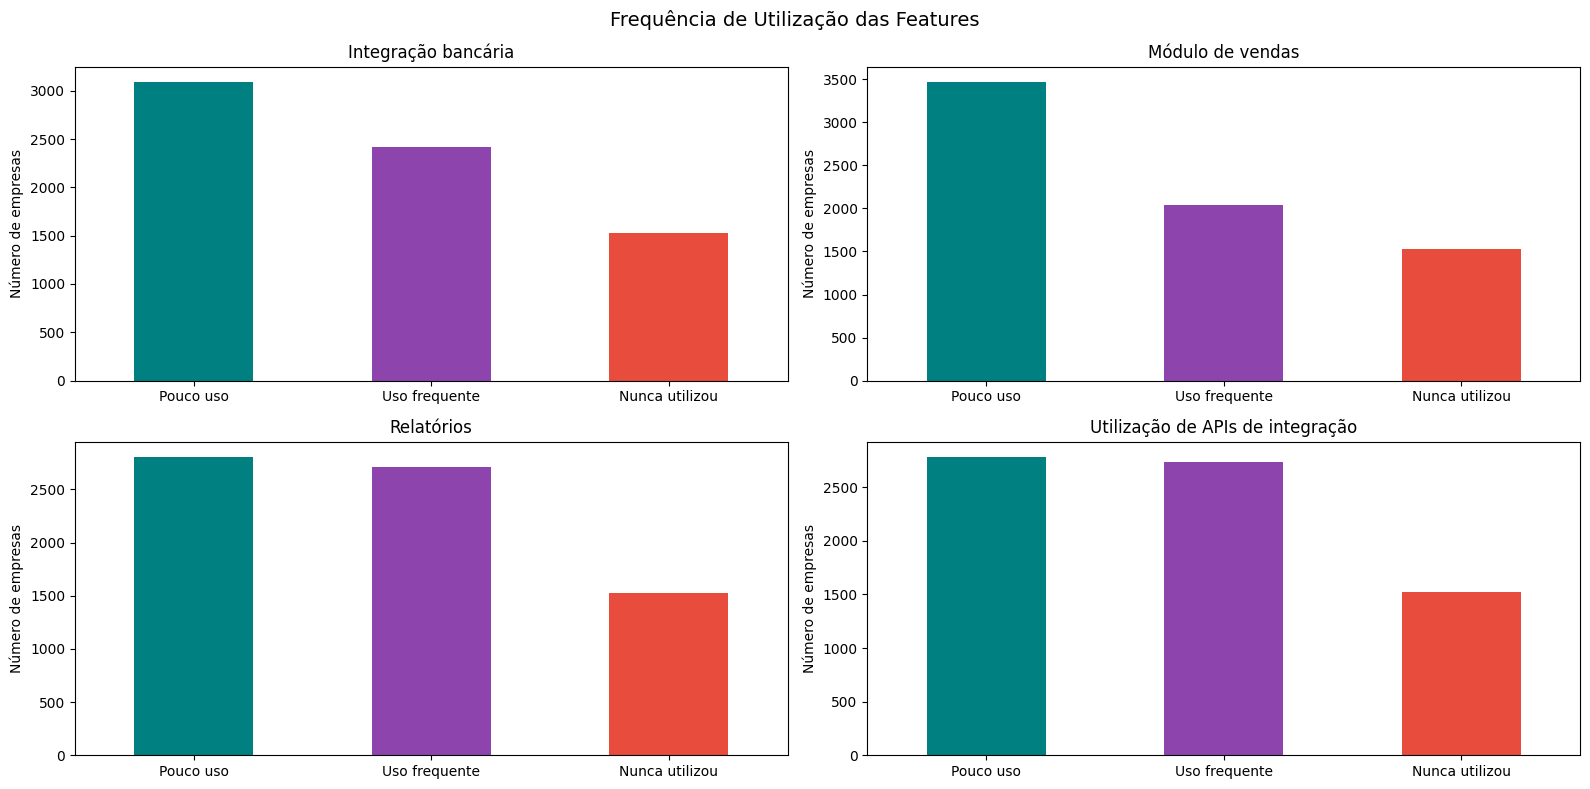


Integração bancária
Pouco uso            3095
Uso frequente        2422
Nunca utilizou       1526

Módulo de vendas
Pouco uso            3473
Uso frequente        2044
Nunca utilizou       1526

Relatórios
Pouco uso            2810
Uso frequente        2707
Nunca utilizou       1526

Utilização de APIs de integração
Pouco uso            2785
Uso frequente        2732
Nunca utilizou       1526


In [47]:
# Colunas de frequência de uso
freq_cols = [
    'Frequência de utilização de feature do sistema: Integração bancária',
    'Frequência de utilização de feature do sistema: Módulo de vendas',
    'Frequência de utilização de feature do sistema: Relatórios',
    'Frequência de utilização de feature do sistema: Utilização de APIs de integração'
]

fig, axs = plt.subplots(2, 2, figsize=(16, 8))
for i, col in enumerate(freq_cols):
    freq_abs = df[col].value_counts()
    ax = axs[i//2, i%2]
    freq_abs.plot(kind='bar', color=['#008080','#8e44ad','#e74c3c'], ax=ax)
    ax.set_title(col.replace('Frequência de utilização de feature do sistema: ', ''))
    ax.set_ylabel('Número de empresas')
    ax.set_xlabel('')
    ax.set_xticklabels(freq_abs.index, rotation=0)
plt.suptitle('Frequência de Utilização das Features', fontsize=14)
plt.tight_layout()
plt.show()

for col, counts in numeros_reais.items():
    nome = col.replace("Frequência de utilização de feature do sistema: ", "")
    print(f'\n{nome}')
    for categoria, valor in counts.items():
        print(f'{categoria:<20} {valor}')

Contrato

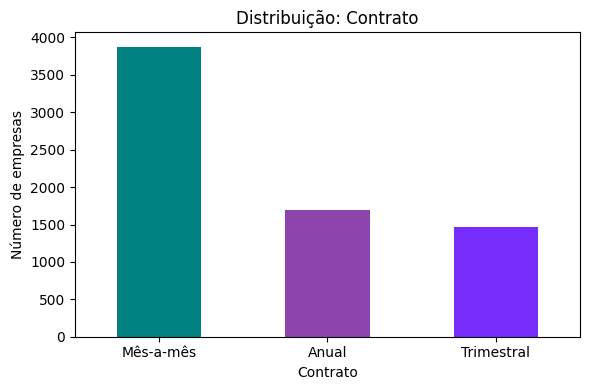

Valores únicos: ['Mês-a-mês' 'Trimestral' 'Anual']
Frequência absoluta: Contrato
Mês-a-mês     3875
Anual         1695
Trimestral    1473
Frequência relativa: Contrato
Mês-a-mês     55.02
Anual         24.07
Trimestral    20.91


In [ ]:
# Análise da coluna 'contrato'
col = 'Contrato'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

#Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind= 'bar', color= ['#008080','#8e44ad','#762CFA'])
plt.title('Distribuição: Contrato')
plt.xlabel('Contrato')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Emite boletos

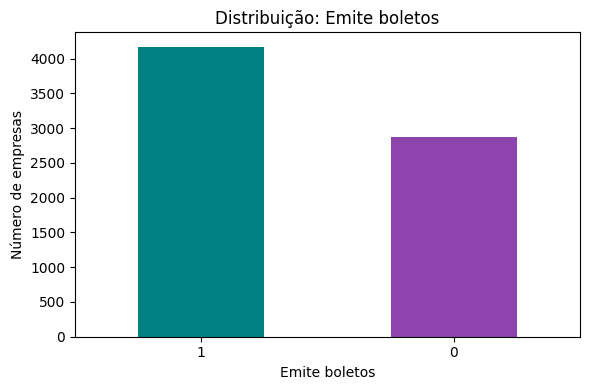

Valores únicos: [1 0]
Frequência absoluta: Emite boletos
1    4171
0    2872
Frequência relativa: Emite boletos
1    59.22
0    40.78


In [ ]:
# Análise da coluna 'Emite boletos'
col = 'Emite boletos'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind= 'bar', color= ['#008080','#8e44ad','#762CFA'])
plt.title('Distribuição: Emite boletos')
plt.xlabel('Emite boletos')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Tipo de pagamento

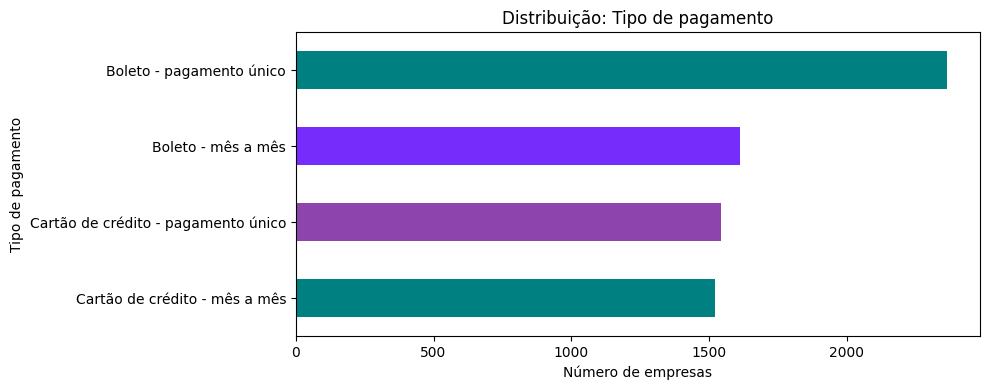

Valores únicos: ['Boleto - pagamento único' 'Boleto - mês a mês'
 'Cartão de crédito - pagamento único' 'Cartão de crédito - mês a mês']
Frequência absoluta: Tipo de pagamento
Boleto - pagamento único               2365
Boleto - mês a mês                     1612
Cartão de crédito - pagamento único    1544
Cartão de crédito - mês a mês          1522
Frequência relativa: Tipo de pagamento
Boleto - pagamento único               33.58
Boleto - mês a mês                     22.89
Cartão de crédito - pagamento único    21.92
Cartão de crédito - mês a mês          21.61


In [ ]:
# Análise da coluna 'Tipo de pagamento'

col = 'Tipo de pagamento'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)


# Gráfico
plt.figure(figsize=(10,4))
freq_abs.sort_values().plot(kind= 'barh', color= ['#008080','#8e44ad','#762CFA'])
plt.title('Distribuição: Tipo de pagamento')
plt.xlabel('Número de empresas')
plt.ylabel('Tipo de pagamento')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Churn

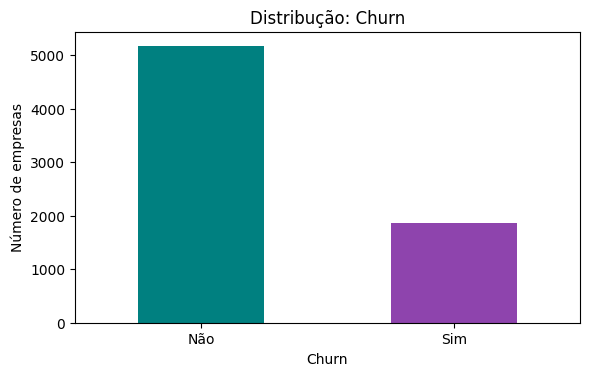

Valores Únicos:['Não' 'Sim']
Frequência absoluta: Churn
Não    5174
Sim    1869
Frequência relativa: Churn
Não    73.46
Sim    26.54


In [10]:
# Análise coluna 'Churn'

col = 'Churn'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Gráfico
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad'])
plt.title('Distribução: Churn')
plt.xlabel('Churn')
plt.ylabel('Número de empresas')
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

print(f'Valores Únicos:{valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Mês churn

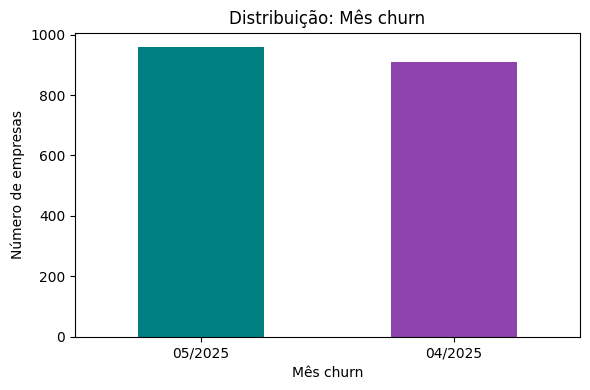

Valores únicos: [nan '04/2025' '05/2025']
Valores nulos: 5174
Frequência absoluta: mes_churn
NaN        5174
05/2025     958
04/2025     911
Frequência relativa: mes_churn
NaN        73.46
05/2025    13.60
04/2025    12.93


In [11]:
# Análise da coluna 'mes_churn'

col = 'mes_churn'

#Valores únicos
valores_unicos = df[col].unique()

#Valores nulos
nulos = df[col].isnull().sum()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts(dropna=False)
freq_rel = round(df[col].value_counts(dropna=False, normalize=True) * 100, 2)

# Gráfico
plt.figure(figsize=(6,4))
df[col].dropna().value_counts().plot(kind= 'bar', color= ['#008080','#8e44ad','#762CFA'])
plt.title('Distribuição: Mês churn')
plt.xlabel('Mês churn')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Valores nulos: {nulos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Insights Gerais:

- A base é composta por micro e pequenas empresas, com 70% dos clientes possuindo até 5 funcionários e apenas 30% com 6 ou mais.

- O uso de serviços financeiros é quase uma característica universal da amostra, atingindo 90,32% dos clientes.

- A variável de contador apresenta 9,68% de valores nulos (682 registros); entre os dados válidos, 48,13% não possuem contador e 42,18% possuem.

- Os contratos mensais predominam com 55%, superando a soma dos modelos anual (24%) e trimestral (21%), o que representa um fator de risco para o churn.

- Existe um grupo fixo de 1.526 registros que "Nunca utilizou" nenhuma das quatro features analisadas, indicando clientes que não ativaram o sistema.

- A taxa de churn é de 26,54%, o que significa que aproximadamente 1 em cada 4 clientes cancelou o serviço.

- Os cancelamentos estão concentrados nos meses de abril e maio de 2025, e os 5.174 valores nulos identificados referem-se apenas aos clientes que não cancelaram, não sendo um problema de qualidade de dados.



### Variáveis Numéricas

Meses de permanência

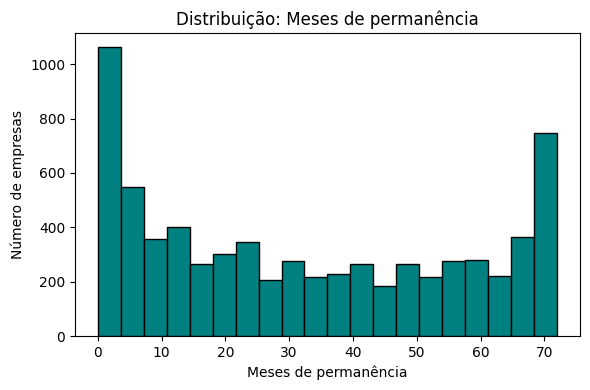

Estatística descritiva:
count    7043.00
mean       32.37
std        24.56
min         0.00
25%         9.00
50%        29.00
75%        55.00
max        72.00


In [8]:
# Análise da coluna 'Meses de permanência'
col = 'Meses de permanência'

# Estatística descritiva
stats = round(df[col].describe(),2)

# Histograma
plt.figure(figsize=(6,4))
plt.hist(df[col], bins=20, edgecolor='black', color= '#008080')
plt.title('Distribuição: Meses de permanência')
plt.xlabel('Meses de permanência')
plt.ylabel('Número de empresas')
plt.tight_layout()
plt.show()

print(f'Estatística descritiva:\n{stats.to_string()}')


Fundação da empresa

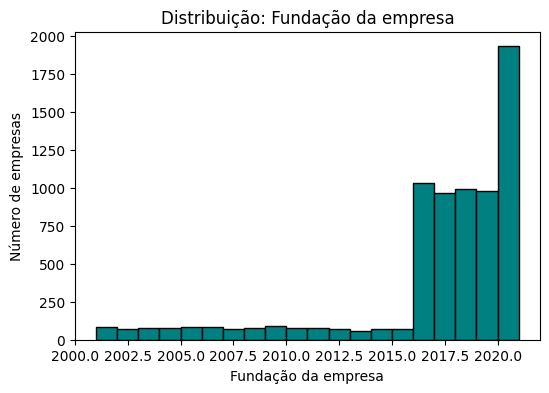

Valores únicos: [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Estatística descritiva:
count    7043.00
mean     2016.74
std         4.58
min      2001.00
25%      2016.00
50%      2018.00
75%      2020.00
max      2021.00
Top 5 anos de fundação: Fundação da empresa
2016    1029
2018     990
2019     982
2021     975
2017     969


In [9]:
## Análise da coluna 'Fundação da empresa'
col = 'Fundação da empresa'  #Extraindo a coluna do DataFrame

#Valores unicos
valores_unicos = df[col].unique() #unique: valores únicos, tolist: transforma em lista, sorted: ordem crescente

# Estatística descritiva
stats = round(df[col].describe(),2)

#Frequência dos anos mais comuns
top_anos = df[col].value_counts().head()

#Histograma
plt.figure(figsize=(6,4))
plt.hist(df[col], bins=20, edgecolor='black', color='#008080')
plt.title('Distribuição: Fundação da empresa')
plt.xlabel('Fundação da empresa')
plt.ylabel('Número de empresas')
plt.show()

print(f'Valores únicos: {sorted(valores_unicos.tolist())}')
print(f'Estatística descritiva:\n{stats.to_string()}')
print(f'Top 5 anos de fundação: {top_anos.to_string()}')

Receita mensal

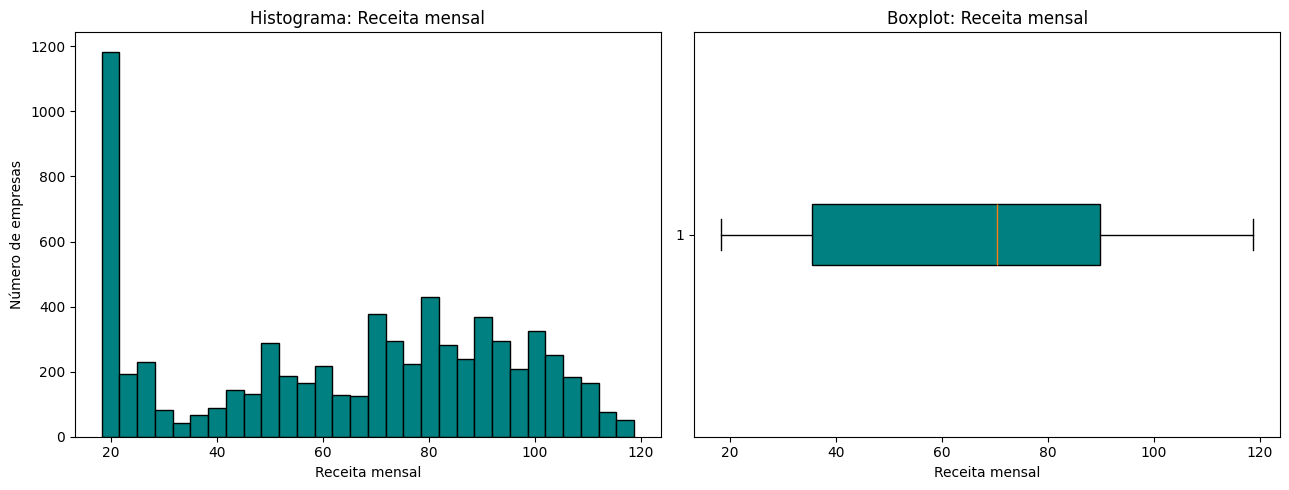

Estatística descritiva:
count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75


In [ ]:
# Análise da coluna 'Receita mensal'

col = 'Receita mensal'

# Estatística
est = round(df[col].describe(),2)

# Boxplot e histograma
fig, axs = plt.subplots(1, 2, figsize=(13,5))
axs[0].hist(df[col].dropna(), bins=30, edgecolor='black', color='#008080') # dropna retira os Nan (vazios)
axs[0].set_title('Histograma: Receita mensal')  # O .set_ é sempre usado para axs[0]
axs[0].set_xlabel('Receita mensal')
axs[0].set_ylabel('Número de empresas')
axs[1].boxplot(df[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='#008080'))   # patch_artist e boxprops para cores
axs[1].set_title('Boxplot: Receita mensal')
axs[1].set_xlabel('Receita mensal')
plt.tight_layout()
plt.show()

print(f'Estatística descritiva:\n{est.to_string()}')  #\n para pular a linha

Receita total

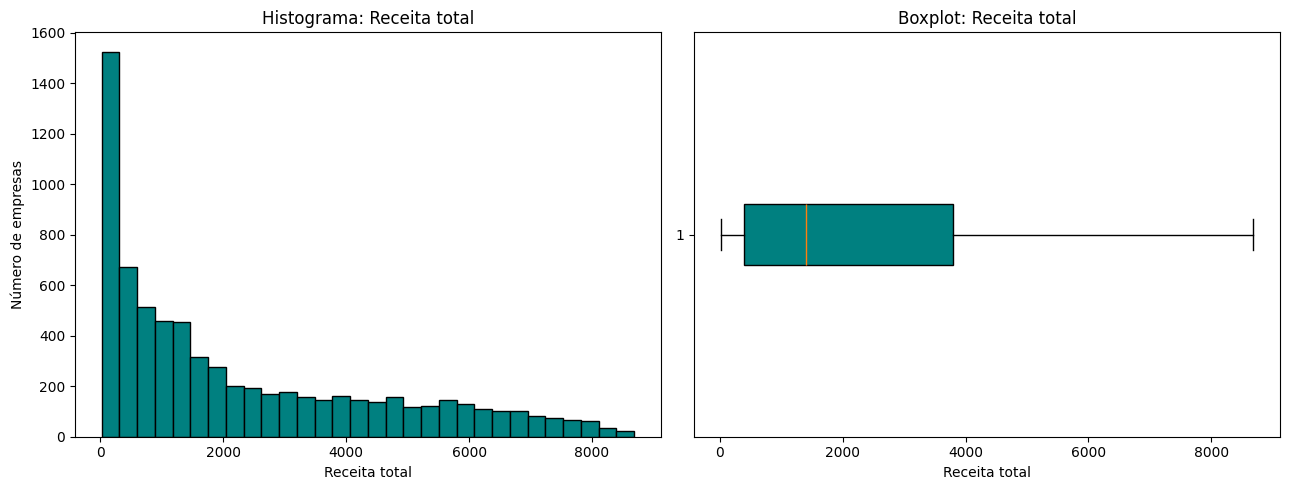

Valores nulos: 11
Estatística descritiva:
count    7032.00
mean     2283.30
std      2266.77
min        18.80
25%       401.45
50%      1397.48
75%      3794.74
max      8684.80


In [ ]:
# Análise da coluna 'Receita total'

col = 'Receita total'

# Valores nulos
nulos = df[col].isnull().sum()

# Estatística descritiva
est = round(df[col].describe(),2)

# Boxplot e histograma
fig, axs = plt.subplots(1, 2, figsize=(13,5))
axs[0].hist(df[col].dropna(), bins=30, edgecolor= 'black', color='#008080')
axs[0].set_title('Histograma: Receita total')
axs[0].set_xlabel('Receita total')
axs[0].set_ylabel('Número de empresas')
axs[1].boxplot(df[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='#008080'))
axs[1].set_title('Boxplot: Receita total')
axs[1].set_xlabel('Receita total')
plt.tight_layout()
plt.show()

print(f'Valores nulos: {nulos}')
print(f'Estatística descritiva:\n{est.to_string()}')

Insights gerais:

## Exploração Multivariada